## DATA QUALITY AND REMEDIAITION

## MISSING VALUE ANALYSIS

In [1]:
import pandas as pd, numpy as np, seaborn as sns

In [2]:
from pydataset import data

In [3]:
airquality = data('airquality')

In [4]:
airquality.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2
3,12.0,149.0,12.6,74,5,3
4,18.0,313.0,11.5,62,5,4
5,NaN,NaN,14.3,56,5,5


In [5]:
airquality.shape

(153, 6)

In [6]:
airquality.columns

Index(['Ozone', 'Solar.R', 'Wind', 'Temp', 'Month', 'Day'], dtype='object')

In [7]:
# CHECKING FOR MISSING VALUES
airquality.isna()

,Ozone,Solar.R,Wind,Temp,Month,Day
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
5,True,True,False,False,False,False
6,False,True,False,False,False,False
7,False,False,False,False,False,False
8,False,False,False,False,False,False
9,False,False,False,False,False,False
10,True,False,False,False,False,False


In [8]:
airquality.isna().sum() #number of missing values column wise

Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

In [9]:
#for the percentage - To check wheather the NA values are less than 5% are not
airquality.isna().sum()/len(airquality)*100

Ozone      24.183007
Solar.R     4.575163
Wind        0.000000
Temp        0.000000
Month       0.000000
Day         0.000000
dtype: float64

## TREATING MISSING VALUES

### IMPUTATION

In [10]:
airquality.mean()

Ozone       42.129310
Solar.R    185.931507
Wind         9.957516
Temp        77.882353
Month        6.993464
Day         15.803922
dtype: float64

In [11]:
airquality_new = airquality.fillna(airquality.mean()) # filling with missing value, do not forget to assing the data

In [12]:
airquality.isna().sum() # old airquality data

Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

In [13]:
airquality_new.isna().sum() # airquality data after imputation

Ozone      0
Solar.R    0
Wind       0
Temp       0
Month      0
Day        0
dtype: int64

### REMOVING MISSING VALUES

In [14]:
airquality_drop = airquality.dropna()

In [15]:
airquality_drop.shape

(111, 6)

## OUTLIERS

In [16]:
iris = data('iris')

<AxesSubplot:>

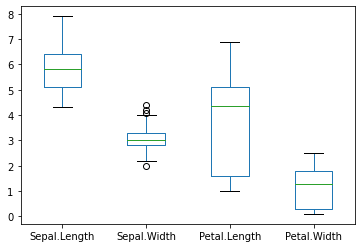

In [17]:
iris.plot(kind = 'box')

## To CALCULATE THE TUKEY'S OUTLIERS

In [18]:
statistics = iris['Sepal.Width'].describe()

In [19]:
Q1 = statistics['25%']
Q3 = statistics['75%']
IQR = Q3 - Q1

In [20]:
lower = Q1 - 1.5*(IQR)
print('lower outlier',lower)
upper = Q3 + 1.5*(IQR)
print('upper outlier',upper)

lower outlier 2.05
upper outlier 4.05


## FINDING THE UNIVARIATE OUTLIERS

#### MY CODE
Can only find the values of Sepal Width

In [21]:
for i in iris.values:
    if i[1] < 2.05 or i[1] > 4.05:
        print(i)

[5.7 4.4 1.5 0.4 'setosa']
[5.2 4.1 1.5 0.1 'setosa']
[5.5 4.2 1.4 0.2 'setosa']
[5.0 2.0 3.5 1.0 'versicolor']


#### SIR CODE
Subsetting the iris dataset depending on the ouliers condition

In [22]:
iris[(iris['Sepal.Width']<2.05) | (iris['Sepal.Width']>4.05)]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
16,5.7,4.4,1.5,0.4,setosa
33,5.2,4.1,1.5,0.1,setosa
34,5.5,4.2,1.4,0.2,setosa
61,5.0,2.0,3.5,1.0,versicolor


In [23]:
iris_outliers_removed = iris.drop(iris.index[[15,32,33,60]],axis = 0)

In [24]:
iris_outliers_removed.shape

(146, 5)

<AxesSubplot:>

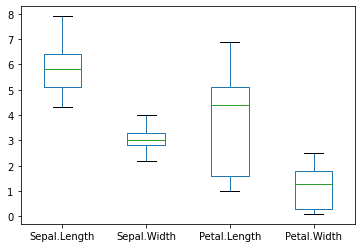

In [25]:
# AFTER REMOVING THE OUTLIERS
iris_outliers_removed.plot(kind = 'box')

## DUPLICATES IN THE DATA

#### IDENTIFYING DUPLICATES IN IRIS DATA

In [29]:
# Gives logical answer
iris.duplicated()

1      False
2      False
3      False
4      False
5      False
6      False
7      False
8      False
9      False
10     False
11     False
12     False
13     False
14     False
15     False
16     False
17     False
18     False
19     False
20     False
21     False
22     False
23     False
24     False
25     False
26     False
27     False
28     False
29     False
30     False
31     False
32     False
33     False
34     False
35     False
36     False
37     False
38     False
39     False
40     False
41     False
42     False
43     False
44     False
45     False
46     False
47     False
48     False
49     False
50     False
51     False
52     False
53     False
54     False
55     False
56     False
57     False
58     False
59     False
60     False
61     False
62     False
63     False
64     False
65     False
66     False
67     False
68     False
69     False
70     False
71     False
72     False
73     False
74     False
75     False
76     False
77     False

In [30]:
# Gives the count
iris.duplicated().sum()

1

#### Drop The Duplicated Rows

In [38]:
iris_unique = iris.drop_duplicates()

In [40]:
iris_unique.duplicated().sum()

0

In [41]:
iris_unique.shape

(149, 5)